In [9]:
from scipy.ndimage import correlate
import numpy as np

input_img = np.arange(25).reshape(5, 5)
print(input_img)

weights = [[0, 1, 0],
		   [1, 2, 1],
		   [0, 1, 0]]

res_img = correlate(input_img, weights)

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]


In [13]:
# 1. Print the value in position (3, 3) in res_img. Explain the value?
print(f"Value at position (3, 3): {res_img[3, 3]}")

# Explanation:
# The correlation operation applies the kernel to each pixel's neighborhood
# For position (3, 3), we look at the 3x3 neighborhood centered at (3, 3)

# Original image around position (3, 3):
# [12, 13, 14]
# [17, 18, 19]  
# [22, 23, 24]

# Kernel (weights):
# [0, 1, 0]
# [1, 2, 1]
# [0, 1, 0]

# Correlation calculation (element-wise multiplication then sum):
# 12*0 + 13*1 + 14*0 +
# 17*1 + 18*2 + 19*1 +
# 22*0 + 23*1 + 24*0
# = 0 + 13 + 0 + 17 + 36 + 19 + 0 + 23 + 0
# = 108

Value at position (3, 3): 108


In [14]:
# 2. Compare the output images when using reflect and constant for the border.
# Where and why do you see the differences.
res_img_constant = correlate(input_img, weights, mode="constant", cval=10)
res_img_reflect = correlate(input_img, weights, mode="reflect")
print("Result with constant border (cval=10):")
print(res_img_constant)
print("Result with reflect border:")
print(res_img_reflect)

# the differences will be seen at the borders of the image.
# In the constant mode, the border pixels are treated as having a constant value (10 in this case),
# which can significantly affect the correlation result at the edges.
# In the reflect mode, the border pixels are mirrored, which tends to preserve the local structure
# of the image better than constant padding, leading to different results at the edges.

Result with constant border (cval=10):
[[ 26  20  25  30  40]
 [ 36  36  42  48  54]
 [ 61  66  72  78  79]
 [ 86  96 102 108 104]
 [ 96 110 115 120 110]]
Result with reflect border:
[[  6  11  17  23  28]
 [ 31  36  42  48  53]
 [ 61  66  72  78  83]
 [ 91  96 102 108 113]
 [116 121 127 133 138]]


/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/823652860.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(image_gray)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/823652860.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


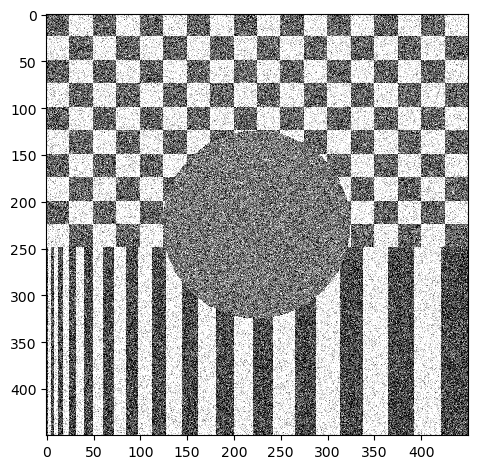

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/823652860.py:21: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(res_img_mean)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/823652860.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


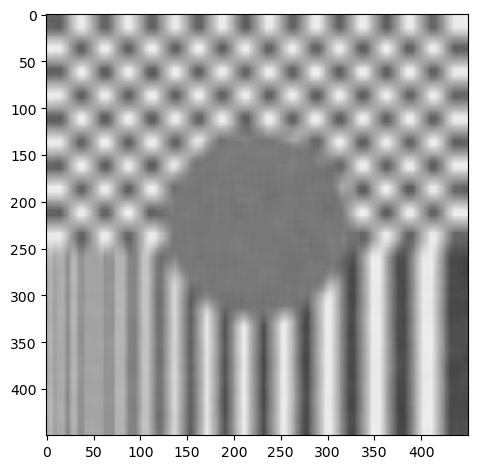

In [17]:
# 3. 
import skimage.io as io
import cv2

image = io.imread('data/Gaussian.png')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

io.imshow(image_gray)
io.show()

size = 20
# Two dimensional filter filled with 1
weights = np.ones([size, size])
# Normalize weights
weights = weights / np.sum(weights)

# Use correlate with the Gaussian.png image and the mean filter.
# Show the resulting image together with the input image. 
# What do you observe?
res_img_mean = correlate(image_gray, weights, mode="reflect")
io.imshow(res_img_mean)
io.show()

# The mean filter smooths the image by averaging the pixel values in the neighborhood defined by the filter size.
# This results in a blurring effect, reducing noise but also potentially losing some detail in the image.


/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/4055077414.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(med_img)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/4055077414.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


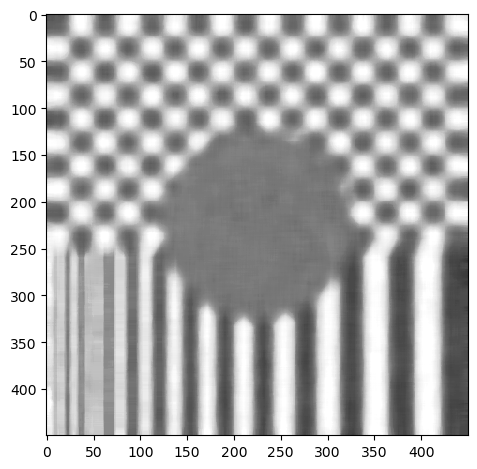

In [19]:
from skimage.filters import median

size = 20
footprint = np.ones([size, size])
med_img = median(image_gray, footprint)

# 4. Filter the Gaussian.png image with the median filter
io.imshow(med_img)
io.show()

# The median filter is effective at removing salt-and-pepper noise while preserving edges better than the mean filter.
# It replaces each pixel value with the median value of the pixels in the neighborhood defined by the footprint.
# This results in a cleaner image with less blurring of edges compared to the mean filter

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/1720050384.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(new_gray)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/1720050384.py:5: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


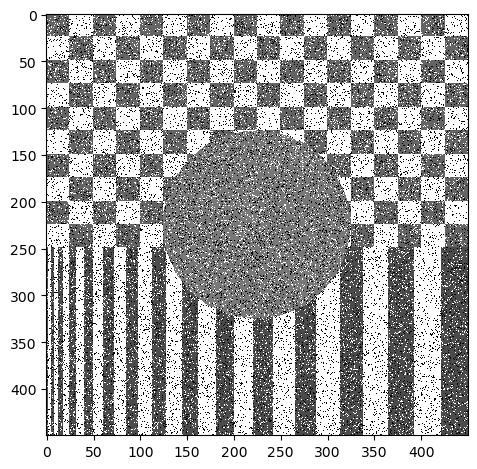

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/1720050384.py:16: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(mean_filtered)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/1720050384.py:17: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


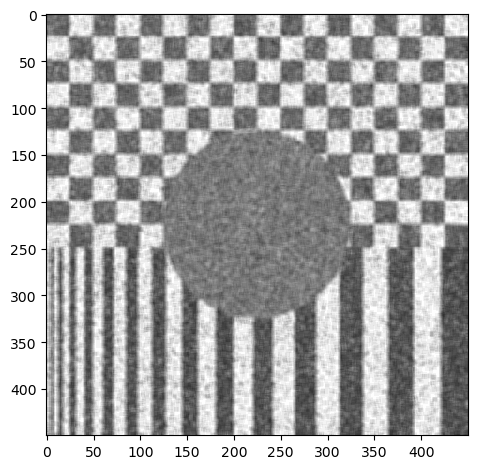

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/1720050384.py:22: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(median_filtered)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/1720050384.py:23: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


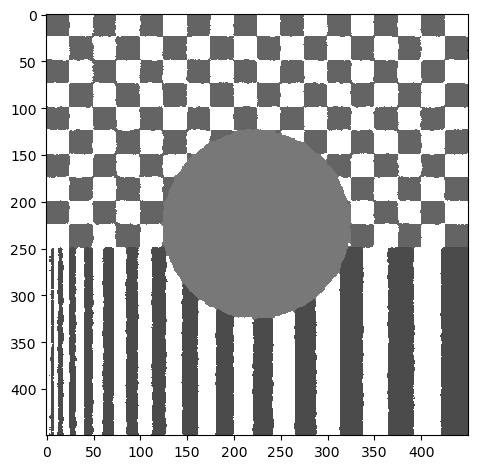

In [24]:
# 5.
new_img = io.imread('data/SaltPepper.png')
new_gray = cv2.cvtColor(new_img, cv2.COLOR_BGR2GRAY)
io.imshow(new_gray)
io.show()

# Make sure to use the correct weights for mean filtering
size = 5
# Two dimensional filter filled with 1
mean_weights = np.ones([size, size])
# Normalize weights
mean_weights = mean_weights / np.sum(mean_weights)

# Filter the SaltPepper.png image with the mean and median filter
mean_filtered = correlate(new_gray, mean_weights, mode="reflect")
io.imshow(mean_filtered)
io.show()

# Use the same footprint as before for median filter
footprint = np.ones([size, size])
median_filtered = median(new_gray, footprint)
io.imshow(median_filtered)
io.show()

# Comparison: The median filter will be much more effective at removing salt-and-pepper noise
# compared to the mean filter, which will blur the noise but not remove it completely.

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/1540942220.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(gauss_img)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/1540942220.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


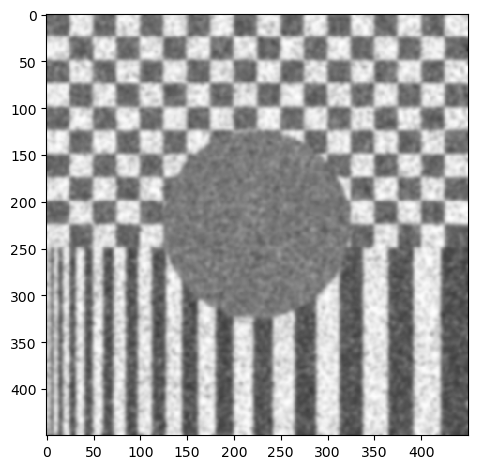

In [33]:
from skimage.filters import gaussian
# 6. 
sigma = 2
gauss_img = gaussian(new_gray, sigma)
io.imshow(gauss_img)
io.show()

# Changing sigma will affect the amount of blurring:
# - A smaller sigma (e.g., 0.5) will result in less blurring, preserving more details.
# - A larger sigma (e.g., 5) will result in more blurring, which can help reduce noise but may also obscure important features in the image.

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/192596180.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(my_gray)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/192596180.py:5: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


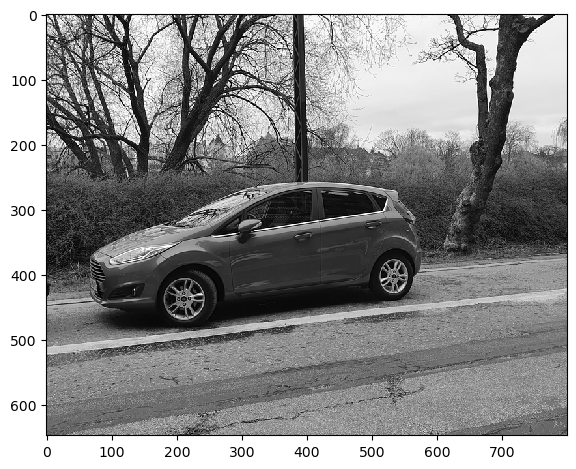

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/192596180.py:12: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(mean_car)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/192596180.py:13: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


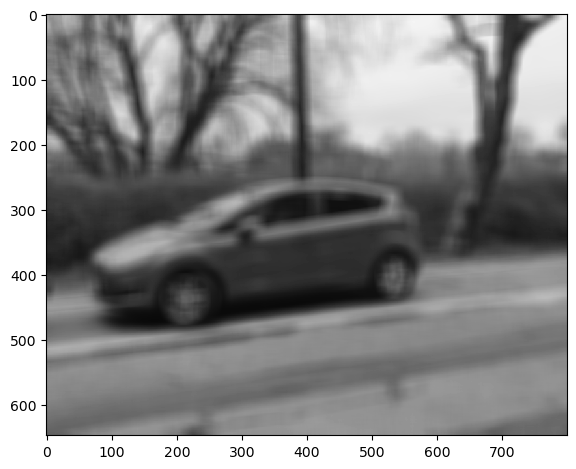

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/192596180.py:18: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(median_car)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/192596180.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


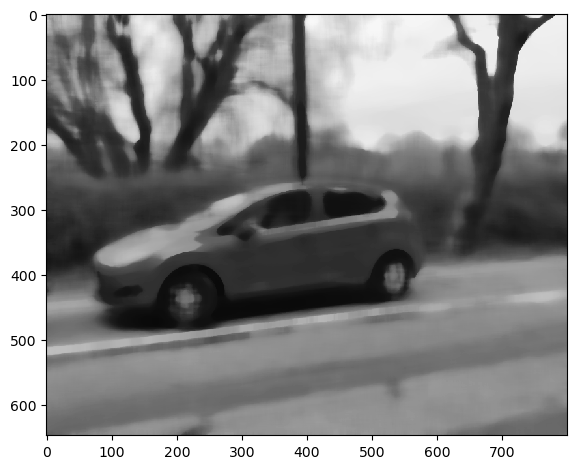

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/192596180.py:24: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(gauss_car)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/192596180.py:25: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


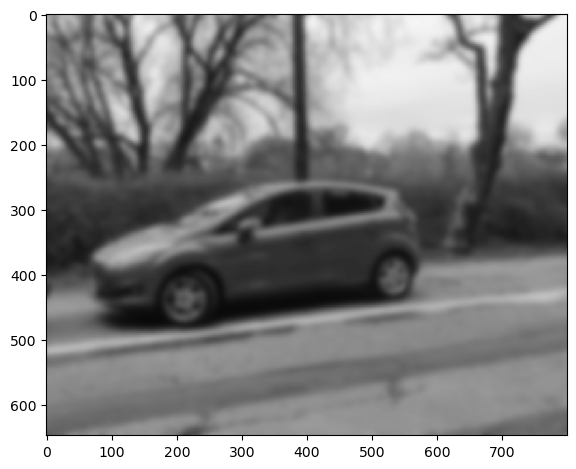

In [37]:
# 7.
my_image = io.imread('data/car.png')
my_gray = cv2.cvtColor(my_image, cv2.COLOR_BGR2GRAY)
io.imshow(my_gray)
io.show()

# mean filter
size = 20
weights = np.ones([size, size])
weights = weights / np.sum(weights)
mean_car = correlate(my_gray, weights, mode="reflect")
io.imshow(mean_car)
io.show()

# median filter
footprint = np.ones([size, size])
median_car = median(my_gray, footprint)
io.imshow(median_car)
io.show()

# gaussian filter
sigma = 5
gauss_car = gaussian(my_gray, sigma)
io.imshow(gauss_car)
io.show()

## Edge filters

In image analysis, an *edge* is where there is a large transition from light pixels to dark pixels. It means that there is a *high pixel value gradient* at an edge. Since objects in an image are often of a different color than the background, the outline of the object can sometimes be found where there are edges in the image. It is therefore interesting to apply filters that can estimate the gradients in the image and using them to detect edges.

The **Prewitt filter** is a simple gradient estimation filter. The Python version of the Prewitt filter can estimate the horizontal gradient using the `prewitt_h` filter, the vertical gradient with the `prewitt_v` filter and the *magnitude of the edges* using the `prewitt` filter. The magnitude is computed as

$$V(x, y) = \sqrt{(P_v^2 + P_h^2)} \enspace , $$

where $P_v$ and $P_h$ are the outputs of the vertical and horizontal Prewitt filters.

Start by importing the filter:

```python
from skimage.filters import prewitt_h
from skimage.filters import prewitt_v
from skimage.filters import prewitt
```

### Exercise 8

Try to filter the **donald_1.png** photo with the `prewitt_h` and `prewitt_v` filters and show the output without converting the output to unsigned byte. Notice that the output range is [-1, 1]. Try to explain what features of the image that gets high and low values when using the two filters?


/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/2730188618.py:9: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(donald_gray)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/2730188618.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


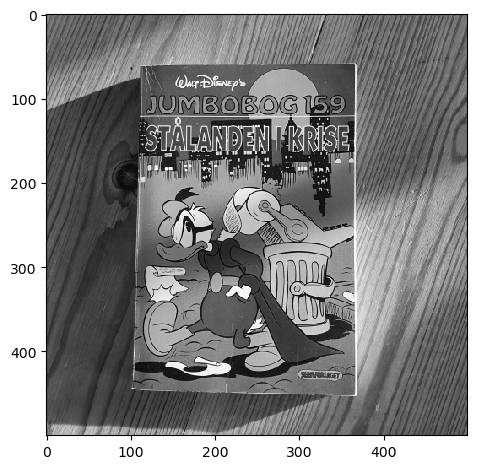

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/2730188618.py:13: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(edges_h)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/2730188618.py:14: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


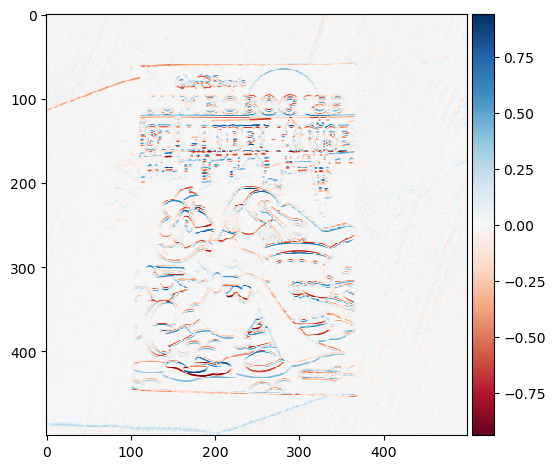

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/2730188618.py:18: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(edges_v)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/2730188618.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


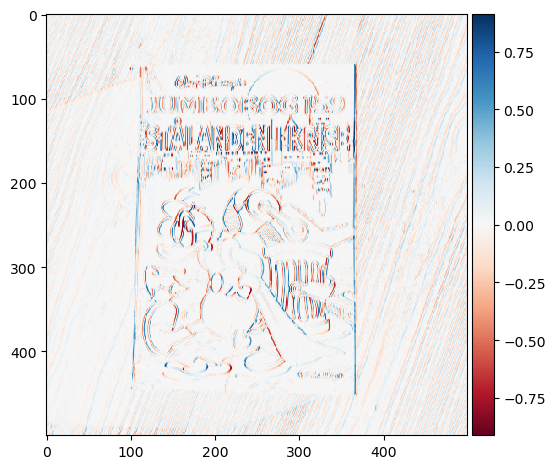

In [39]:
from skimage.filters import prewitt_h
from skimage.filters import prewitt_v
from skimage.filters import prewitt

# 8.

donald_img = io.imread('data/donald_1.png')
donald_gray = cv2.cvtColor(donald_img, cv2.COLOR_BGR2GRAY)
io.imshow(donald_gray)
io.show()
# Horizontal edges
edges_h = prewitt_h(donald_gray)
io.imshow(edges_h)
io.show()

# Vertical edges
edges_v = prewitt_v(donald_gray)
io.imshow(edges_v)
io.show()

# The features that get high and low values in the two images
# Horizontal edges image (edges_h) will highlight horizontal transitions in intensity,
# such as the edges of the hat and the mouth.
# Vertical edges image (edges_v) will highlight vertical transitions in intensity,
# such as the edges of the face and the sides of the hat.
# Areas with little to no horizontal or vertical change will have low values in the respective edge images

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/1416710433.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(edges)
/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_93424/1416710433.py:5: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


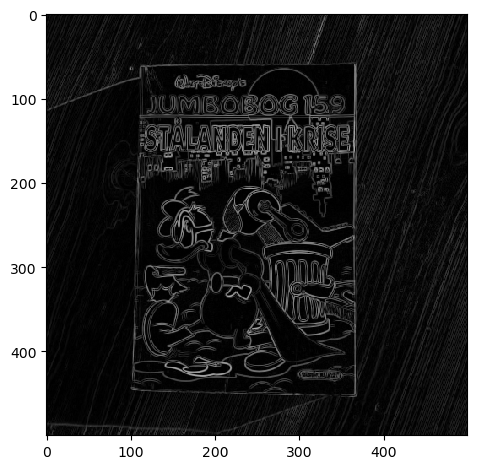

In [40]:
# 9. Use the prewitt filter on donald_1.png. What do you see?

edges = prewitt(donald_gray)
io.imshow(edges)
io.show()

# The combined Prewitt filter highlights edges in all directions, providing a more comprehensive edge map of the image.

In [1]:
# 10.
from skimage.filters import threshold_otsu

ct_img = io.imread('data/ElbowCTSlice.png')
ct_gray = cv2.cvtColor(ct_img, cv2.COLOR_BGR2GRAY)
io.imshow(ct_gray)
io.show()

# Filter the image with median filter
size = 12
footprint = np.ones([size, size])
ct_median = median(ct_gray, footprint)

# filter the image with gaussian filter
sigma = 2
ct_gauss = gaussian(ct_median, sigma)

# Compute the gradient of the image using the Prewitt filter
ct_edges = prewitt(ct_gauss)

# Otsu's method to find a threshold value
thresh = threshold_otsu(ct_edges)
print(f"Otsu's threshold: {thresh}")

# Create a binary image using the threshold
binary_img = ct_edges > thresh
io.imshow(binary_img)
io.show()

min_val = ct_edges.min()
max_val = ct_edges.max()
io.imshow(ct_edges, vmin=min_val, vmax=max_val, cmap="terrain")

NameError: name 'io' is not defined

In [ ]:
from skimage import color
from skimage.util import img_as_ubyte
from skimage.util import img_as_float
from skimage.filters import prewitt
from skimage.filters import threshold_otsu
from skimage.filters import median
import time
import cv2
import numpy as np

def show_in_moved_window(win_name, img, x, y):
    """
    Show an image in a window, where the position of the window can be given
    """
    cv2.namedWindow(win_name)
    cv2.moveWindow(win_name, x, y)
    cv2.imshow(win_name, img)


def process_gray_image(img):
    """
    Do a simple processing of an input gray scale image and return the processed image.
    # https://scikit-image.org/docs/stable/user_guide/data_types.html#image-processing-pipeline
    """
    # Do something here:
    # 11. Filter the image with a Prewitt filter followed by Otsu thresholding
    proc_img = prewitt(img)
    proc_img = threshold_otsu(proc_img)
    proc_img = img > proc_img
    
    # 12. Filter the image with a median filter
    size = 10
    footprint = np.ones([size, size])
    proc_img = median(img, footprint)
    # The median filter kills the fps
    return img_as_ubyte(proc_img)


def process_rgb_image(img):
    """
    Simple processing of a color (RGB) image
    """
    # Copy the image information so we do not change the original image
    proc_img = img.copy()
    r_comp = proc_img[:, :, 0]
    proc_img[:, :, 0] = 1 - r_comp
    return proc_img


def capture_from_camera_and_show_images():
    print("Starting image capture")

    print("Opening connection to camera")
    url = 0
    use_droid_cam = False
    if use_droid_cam:
        url = "http://192.168.1.120:4747/video"
    cap = cv2.VideoCapture(url)
    if not cap.isOpened():
        print("Cannot open camera")
        exit()

    print("Starting camera loop")
    # To keep track of frames per second using a high-performance counter
    old_time = time.perf_counter()
    fps = 0
    stop = False
    process_rgb = False
    while not stop:
        ret, new_frame = cap.read()
        if not ret:
            print("Can't receive frame. Exiting ...")
            break

        # Change from OpenCV BGR to scikit image RGB
        new_image = new_frame[:, :, ::-1]
        new_image_gray = color.rgb2gray(new_image)
        if process_rgb:
            proc_img = process_rgb_image(new_image)
            # convert back to OpenCV BGR to show it
            proc_img = proc_img[:, :, ::-1]
        else:
            proc_img = process_gray_image(new_image_gray)

        # update FPS - but do it slowly to avoid fast changing number
        new_time = time.perf_counter()
        time_dif = new_time - old_time
        old_time = new_time
        fps = fps * 0.95 + 0.05 * 1 / time_dif

        # Put the FPS on the new_frame
        str_out = f"fps: {int(fps)}"
        font = cv2.FONT_HERSHEY_COMPLEX
        cv2.putText(new_frame, str_out, (100, 100), font, 1, 255, 1)

        # Display the resulting frame
        show_in_moved_window('Input', new_frame, 0, 10)
        show_in_moved_window('Input gray', new_image_gray, 600, 10)
        show_in_moved_window('Processed image', proc_img, 1200, 10)

        if cv2.waitKey(1) == ord('q'):
            stop = True

    print("Stopping image loop")
    cap.release()
    cv2.destroyAllWindows()


if __name__ == '__main__':
    capture_from_camera_and_show_images()


Starting image capture
Opening connection to camera


2025-10-14 11:47:09.700 python[94968:1982258] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


Starting camera loop
Stopping image loop


: 